# 02 Polar Verity Sense Offline Runbook

## A. Setup

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_ROOT = Path.cwd()
LIB_ROOT = NOTEBOOK_ROOT / "lib"
if str(LIB_ROOT) not in sys.path:
    sys.path.insert(0, str(LIB_ROOT))

from session_discovery import list_sessions
from remote_sync import get_session_by_id
from pipeline_client import run_full_pipeline
from session_loader import load_summary, load_clean, load_window_features, load_raw_chunks
from eda_helpers import compute_gap_stats, ensure_datetime, pick_first_column

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

In [ ]:
# Runtime parameters
user_id = 1
session_id_override = "fd3f0c8c-6e00-45ae-9290-38002e00abc9"  # set specific session id if needed
user_id_candidates = [1, 2]  # fallback search when session_id_override is set
max_rows_per_stream = 100000
env_path = NOTEBOOK_ROOT / ".env"
plot_points = 4000
live_progress = False  # avoid SSH progress polling loop issues

## B. Session Discovery

In [3]:
sessions = list_sessions(user_id=user_id, env_path=env_path)
offline_sessions = [s for s in sessions if str(s.get("source","")).lower() == "polar_verity_sense" and str(s.get("collection_mode","")).lower() == "offline_recording"]
print(f"discovered={len(sessions)} offline_verity={len(offline_sessions)}")
pd.DataFrame(offline_sessions).head(20)

discovered=0 offline_verity=0


""


In [4]:
if session_id_override:
    # Resolve correct user_id for explicit session_id override.
    matched_user_id = None
    for candidate_user_id in user_id_candidates:
        try:
            candidate_sessions = list_sessions(user_id=candidate_user_id, env_path=env_path)
        except Exception:
            continue
        if any(str(item.get("session_id")) == str(session_id_override) for item in candidate_sessions):
            matched_user_id = candidate_user_id
            break

    if matched_user_id is not None:
        user_id = matched_user_id
    session_id = session_id_override
elif offline_sessions:
    session_id = str(offline_sessions[0]["session_id"])
else:
    raise RuntimeError("No Polar Verity Sense offline sessions found. Set session_id_override.")

print("user_id:", user_id)
print("session_id:", session_id)


user_id: 1
session_id: f20f5ed7-55e2-46d1-99b5-12368729a254


## C. Run Pipeline

In [5]:
pipeline_result = run_full_pipeline(
    session_id=session_id,
    user_id=user_id,
    env_path=env_path,
    live_progress=False,
)
pipeline_result

Final step summary:
[normalize] status=success streams: success=6 skipped=0 failed=0
[window_features] status=success streams: success=6 skipped=0 failed=0
[build_session_summary] status=partial streams: success=6 skipped=0 failed=0


{'response': {'sessions_discovered': 1,
  'normalize_runs': [{'run_id': 'acdfa2147a104db8bfc5ea2aa2f34ccc',
    'status': 'success',
    'session_id': 'f20f5ed7-55e2-46d1-99b5-12368729a254',
    'step_name': 'normalize',
    'state_path': '/data/wearable/pipeline_runs/normalize/acdfa2147a104db8bfc5ea2aa2f34ccc.json',
    'discovered_streams': ['acc', 'gyro', 'hr', 'mag', 'ppg', 'ppi'],
    'per_stream_results': [{'stream_type': 'acc',
      'handler_name': 'PolarVerityOfflineNormalizer',
      'status': 'success',
      'input_path': '/data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-05/session_id=f20f5ed7-55e2-46d1-99b5-12368729a254/streams/acc/chunks.jsonl',
      'output_path': '/data/wearable/processed/clean_timeseries/user_id=2/source=polar_verity_sense/session_id=f20f5ed7-55e2-46d1-99b5-12368729a254/streams/acc/data.parquet',
      'error': None},
     {'stream_type': 'gyro',
      'handler_name': 'PolarVerityOfflineNormalizer',
      'status': 'success',
      

## D. Sync Data

In [6]:
session_cache_path = get_session_by_id(session_id=session_id, env_path=env_path)
print(session_cache_path)

notebooks/data_cache/session_id=f20f5ed7-55e2-46d1-99b5-12368729a254


import json
## E. Load Artifacts

In [7]:
summary = load_summary(session_cache_path)
clean = load_clean(session_cache_path, max_rows_per_stream=max_rows_per_stream)
window_features = load_window_features(session_cache_path, max_rows_per_stream=max_rows_per_stream)
raw = load_raw_chunks(session_cache_path, preview_rows_per_stream=20, max_scan_lines_per_stream=5000)

print("clean streams:", sorted(clean.keys()))
print("window streams:", sorted(window_features.keys()))
print("raw streams:", sorted(raw.keys()))
summary.get("_source_path")

clean streams: ['acc', 'gyro', 'hr', 'mag', 'ppg', 'ppi']
window streams: ['acc', 'gyro', 'hr', 'mag', 'ppg', 'ppi']
raw streams: ['acc', 'gyro', 'hr', 'mag', 'ppg', 'ppi']


'notebooks/data_cache/session_id=f20f5ed7-55e2-46d1-99b5-12368729a254/data/wearable/processed/window_features/user_id=2/source=polar_verity_sense/session_id=f20f5ed7-55e2-46d1-99b5-12368729a254/session_summary.json'

## F. Time Alignment Reports

In [8]:
report_paths = sorted(Path(session_cache_path).glob("**/processed/clean_timeseries/**/time_alignment_report.json"))
reports = []
for p in report_paths:
    payload = json.loads(p.read_text(encoding="utf-8"))
    payload["_path"] = str(p)
    reports.append(payload)

report_df = pd.DataFrame([
    {
        "stream_type": r.get("stream_type"),
        "alignment_basis": r.get("alignment_basis"),
        "epoch_offset_decision": r.get("epoch_offset_decision"),
        "confidence": r.get("confidence"),
        "samples_count": r.get("samples_count"),
        "start_utc": (r.get("normalized_time_range") or {}).get("start_utc"),
        "end_utc": (r.get("normalized_time_range") or {}).get("end_utc"),
        "warnings": "; ".join(r.get("warnings") or []),
        "path": r.get("_path"),
    }
    for r in reports
])
report_df.sort_values(["stream_type"]).reset_index(drop=True) if not report_df.empty else report_df

,stream_type,alignment_basis,epoch_offset_decision,confidence,samples_count,start_utc,end_utc,warnings,path
0,acc,payload.samples[].timeStamp,polar_epoch_ns_direct,high,540,2026-05-05T05:59:25.210557184Z,2026-05-05T05:59:38.125021772Z,,notebooks/data_cache/session_id=f20f5ed7-55e2-...
1,gyro,payload.samples[].timeStamp,polar_epoch_ns_direct,high,560,2026-05-05T05:59:25.988600576Z,2026-05-05T05:59:39.300941348Z,,notebooks/data_cache/session_id=f20f5ed7-55e2-...
2,hr,reconstructed_from_collector_and_cadence,no_sample_timestamp,low,15,2026-05-05T05:59:43.957000Z,2026-05-05T05:59:57.957000Z,,notebooks/data_cache/session_id=f20f5ed7-55e2-...
3,mag,payload.samples[].timeStamp,polar_epoch_ns_direct,high,760,2026-05-05T05:59:25.757814016Z,2026-05-05T05:59:41.146914132Z,,notebooks/data_cache/session_id=f20f5ed7-55e2-...
4,ppg,payload.samples[].timeStamp,polar_epoch_ns_direct,high,700,2026-05-05T05:59:27.188692480Z,2026-05-05T05:59:42.050643666Z,,notebooks/data_cache/session_id=f20f5ed7-55e2-...
5,ppi,payload.samples[].timeStamp,polar_epoch_ns_shifted_to_collector,medium,30934,2026-05-05T05:58:05.092000064Z,2026-05-05T05:59:00.851000064Z,applied timestamp shift from collector referen...,notebooks/data_cache/session_id=f20f5ed7-55e2-...


## G. Stream Quality Checks

In [9]:
rows=[]
for stream, df in clean.items():
    local, ts_col = ensure_datetime(df)
    if ts_col is None or local.empty:
        rows.append({"stream":stream,"rows":len(df.index),"ts_col":ts_col,"duration_s":None,"median_delta_s":None,"max_delta_s":None,"duplicates":None})
        continue
    gaps = compute_gap_stats(local[ts_col])
    duration = (local[ts_col].max() - local[ts_col].min()).total_seconds() if len(local.index)>1 else 0
    rows.append({
        "stream":stream,
        "rows":len(local.index),
        "ts_col":ts_col,
        "duration_s":float(duration),
        "median_delta_s":gaps.median_delta_seconds,
        "max_delta_s":gaps.max_delta_seconds,
        "duplicates":gaps.duplicate_timestamps,
    })

pd.DataFrame(rows).sort_values("stream")

,stream,rows,ts_col,duration_s,median_delta_s,max_delta_s,duplicates
0,acc,540,ts_utc,12.914464,0.019598,0.044836,0
1,gyro,560,ts_utc,13.312340,0.019598,0.045872,0
2,hr,15,ts_utc,14.000000,1.000000,1.000000,0
3,mag,760,ts_utc,15.389100,0.020326,0.020333,0
4,ppg,700,ts_utc,14.861951,0.018241,0.098589,0
5,ppi,30934,ts_utc,55.759000,0.001045,0.626506,3845


## H. Stream Tables And Plots


### acc ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,raw_sample_timestamp_ns,sample_index,vector_magnitude,x,y,z
0,2026-05-05 05:59:25.210557184+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.862Z,2026-05-05T05:59:44.907273Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-acc-f20f5ed7-55e2-46d1-99b5-123...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,8bb07409-e800-40e8-806c-972c0e70c707,1,1,high,831275965210557184,0,985.999493,-115.0,-971.0,127.0
1,2026-05-05 05:59:25.229787904+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.862Z,2026-05-05T05:59:44.907273Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-acc-f20f5ed7-55e2-46d1-99b5-123...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,8bb07409-e800-40e8-806c-972c0e70c707,1,1,high,831275965229787904,1,984.172749,-104.0,-972.0,114.0
2,2026-05-05 05:59:25.249018752+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.862Z,2026-05-05T05:59:44.907273Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-acc-f20f5ed7-55e2-46d1-99b5-123...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,8bb07409-e800-40e8-806c-972c0e70c707,1,1,high,831275965249018752,2,985.821992,-104.0,-975.0,102.0
3,2026-05-05 05:59:25.268249472+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.862Z,2026-05-05T05:59:44.907273Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-acc-f20f5ed7-55e2-46d1-99b5-123...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,8bb07409-e800-40e8-806c-972c0e70c707,1,1,high,831275965268249472,3,979.106736,-115.0,-964.0,127.0
4,2026-05-05 05:59:25.287480320+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.862Z,2026-05-05T05:59:44.907273Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-acc-f20f5ed7-55e2-46d1-99b5-123...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,8bb07409-e800-40e8-806c-972c0e70c707,1,1,high,831275965287480320,4,990.182811,-109.0,-975.0,134.0
5,2026-05-05 05:59:25.306711040+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.862Z,2026-05-05T05:59:44.907273Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-acc-f20f5ed7-55e2-46d1-99b5-123...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,8bb07409-e800-40e8-806c-972c0e70c707,1,1,high,831275965306711040,5,986.876892,-118.0,-971.0,131.0
6,2026-05-05 05:59:25.325941760+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.862Z,2026-05-05T05:59:44.907273Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-acc-f20f5ed7-55e2-46d1-99b5-123...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,8bb07409-e800-40e8-806c-972c0e70c707,1,1,high,831275965325941760,6,978.629654,-112.0,-964.0,126.0
7,2026-05-05 05:59:25.345172608+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.862Z,2026-05-05T05:59:44.907273Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-acc-f20f5ed7-55e2-46d1-99b5-123...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,8bb07409-e800-40e8-806c-972c0e70c707,1,1,high,831275965345172608,7,982.973550,-116.0,-970.0,109.0
8,2026-05-05 05:59:25.364403328+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.862Z,2026-05-05T05:59:44.907273Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-acc-f20f5ed7-55e2-46d1-99b5-123...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,8bb07409-e800-40e8-806c-972c0e70c707,1,1,high,831275965364403328,8,988.797755,-122.0,-974.0,119.0
9,2026-05-05 05:59:25.383634048+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.862Z,2026-05-05T05:59:44.907273Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-acc-f20f5ed7-55e2-46d1-99b5-123...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,8bb07409-e800-40e8-806c-972c0e70c707,1,1,high,8312759653836340

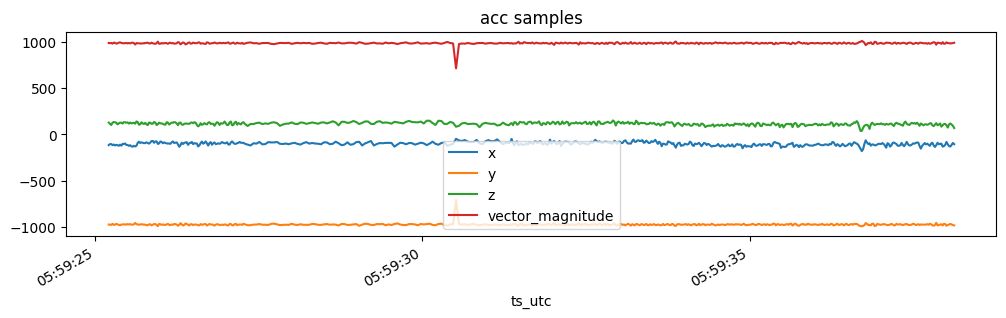


### gyro ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,raw_sample_timestamp_ns,sample_index,vector_magnitude,x,y,z
0,2026-05-05 05:59:25.988600576+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.206Z,2026-05-05T05:59:45.255940Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-gyro-f20f5ed7-55e2-46d1-99b5-12...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,22f71d12-3e0a-46f0-be1f-88d08ef25bfe,1,1,high,831275965988600576,0,2.541299,-1.47,-0.42,-2.03
1,2026-05-05 05:59:26.007831296+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.206Z,2026-05-05T05:59:45.255940Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-gyro-f20f5ed7-55e2-46d1-99b5-12...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,22f71d12-3e0a-46f0-be1f-88d08ef25bfe,1,1,high,831275966007831296,1,1.716071,-1.68,-0.28,0.21
2,2026-05-05 05:59:26.027062144+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.206Z,2026-05-05T05:59:45.255940Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-gyro-f20f5ed7-55e2-46d1-99b5-12...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,22f71d12-3e0a-46f0-be1f-88d08ef25bfe,1,1,high,831275966027062144,2,3.095868,-1.40,-2.38,1.40
3,2026-05-05 05:59:26.046292864+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.206Z,2026-05-05T05:59:45.255940Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-gyro-f20f5ed7-55e2-46d1-99b5-12...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,22f71d12-3e0a-46f0-be1f-88d08ef25bfe,1,1,high,831275966046292864,3,3.920625,-1.19,-3.64,0.84
4,2026-05-05 05:59:26.065523712+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.206Z,2026-05-05T05:59:45.255940Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-gyro-f20f5ed7-55e2-46d1-99b5-12...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,22f71d12-3e0a-46f0-be1f-88d08ef25bfe,1,1,high,831275966065523712,4,2.106988,-1.12,-1.61,0.77
5,2026-05-05 05:59:26.084754432+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.206Z,2026-05-05T05:59:45.255940Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-gyro-f20f5ed7-55e2-46d1-99b5-12...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,22f71d12-3e0a-46f0-be1f-88d08ef25bfe,1,1,high,831275966084754432,5,1.815957,-1.47,-0.98,0.42
6,2026-05-05 05:59:26.103985152+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.206Z,2026-05-05T05:59:45.255940Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-gyro-f20f5ed7-55e2-46d1-99b5-12...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,22f71d12-3e0a-46f0-be1f-88d08ef25bfe,1,1,high,831275966103985152,6,2.524856,-1.40,-2.10,-0.07
7,2026-05-05 05:59:26.123216+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.206Z,2026-05-05T05:59:45.255940Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-gyro-f20f5ed7-55e2-46d1-99b5-12...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,22f71d12-3e0a-46f0-be1f-88d08ef25bfe,1,1,high,831275966123216000,7,1.937369,-1.19,-1.47,0.42
8,2026-05-05 05:59:26.142446720+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.206Z,2026-05-05T05:59:45.255940Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-gyro-f20f5ed7-55e2-46d1-99b5-12...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,22f71d12-3e0a-46f0-be1f-88d08ef25bfe,1,1,high,831275966142446720,8,1.597780,-1.05,-0.98,0.70
9,2026-05-05 05:59:26.161677440+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.206Z,2026-05-05T05:59:45.255940Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-gyro-f20f5ed7-55e2-46d1-99b5-12...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,22f71d12-3e0a-46f0-be1f-88d08ef25bfe,1,1,high,831275966161677440,9,1.992235,-1.40,-1.33,

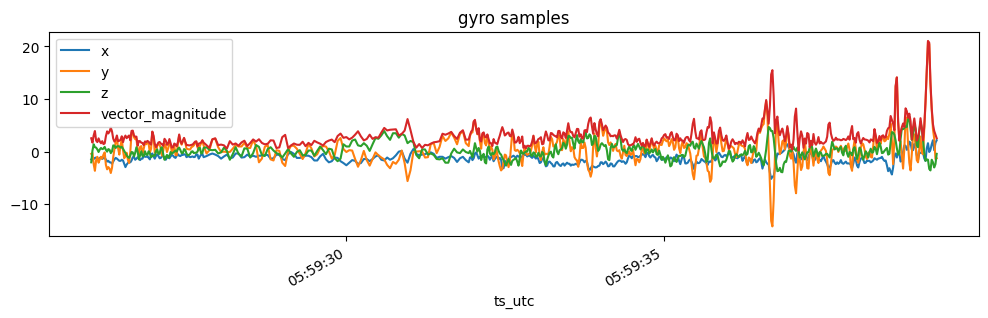


### hr ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,contact_status,contact_status_supported,corrected_hr,hr,ppg_quality,raw_sample_timestamp_ns,rr_available,rrs_ms,sample_index
0,2026-05-05 05:59:43.957000+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.836Z,2026-05-05T05:59:44.856659Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-hr-f20f5ed7-55e2-46d1-99b5-1236...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,c6d9733b-c9e4-4fd1-b317-1dad327d2fa8,1,1,low,False,False,0,69,0,None,False,[],1
1,2026-05-05 05:59:44.957000+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.836Z,2026-05-05T05:59:44.856659Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-hr-f20f5ed7-55e2-46d1-99b5-1236...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,c6d9733b-c9e4-4fd1-b317-1dad327d2fa8,1,1,low,False,False,0,68,0,None,False,[],2
2,2026-05-05 05:59:45.957000+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.836Z,2026-05-05T05:59:44.856659Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-hr-f20f5ed7-55e2-46d1-99b5-1236...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,c6d9733b-c9e4-4fd1-b317-1dad327d2fa8,1,1,low,False,False,0,68,0,None,False,[],3
3,2026-05-05 05:59:46.957000+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.836Z,2026-05-05T05:59:44.856659Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-hr-f20f5ed7-55e2-46d1-99b5-1236...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,c6d9733b-c9e4-4fd1-b317-1dad327d2fa8,1,1,low,False,False,0,67,0,None,False,[],4
4,2026-05-05 05:59:47.957000+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.836Z,2026-05-05T05:59:44.856659Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-hr-f20f5ed7-55e2-46d1-99b5-1236...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,c6d9733b-c9e4-4fd1-b317-1dad327d2fa8,1,1,low,False,False,0,0,0,None,False,[],5
5,2026-05-05 05:59:48.957000+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.836Z,2026-05-05T05:59:44.856659Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-hr-f20f5ed7-55e2-46d1-99b5-1236...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,c6d9733b-c9e4-4fd1-b317-1dad327d2fa8,1,1,low,False,False,0,0,0,None,False,[],6
6,2026-05-05 05:59:49.957000+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.836Z,2026-05-05T05:59:44.856659Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-hr-f20f5ed7-55e2-46d1-99b5-1236...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,c6d9733b-c9e4-4fd1-b317-1dad327d2fa8,1,1,low,False,False,0,0,0,None,False,[],7
7,2026-05-05 05:59:50.957000+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.836Z,2026-05-05T05:59:44.856659Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-hr-f20f5ed7-55e2-46d1-99b5-1236...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,c6d9733b-c9e4-4fd1-b317-1dad327d2fa8,1,1,low,False,False,0,0,0,None,False,[],8
8,2026-05-05 05:59:51.957000+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.836Z,2026-05-05T05:59:44.856659Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-hr-f20f5ed7-55e2-46d1-99b5-1236...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,c6d9733b-c9e4-4fd1-b317-1dad327d2fa8,1,1,low,False,False,0,0,0,None,False,[],9
9,2026-05-05 05:59:52.957000+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.836Z,2026-05-05T05:59:44.856659Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-hr-f20f5ed7-55e2-46d1-99b5-1236...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,c6d9733b-c9e4-4fd1-b317-1dad327d2fa8,1,1,low,False,False,0,0,0,None,False,[],10


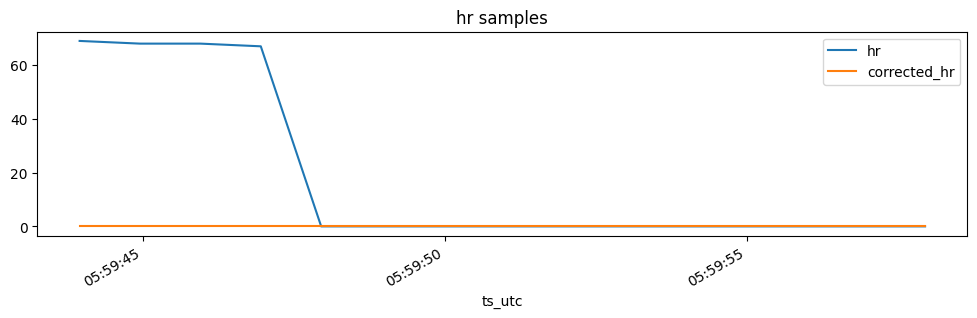


### mag ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,raw_sample_timestamp_ns,sample_index,vector_magnitude,x,y,z
0,2026-05-05 05:59:25.757814016+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.125Z,2026-05-05T05:59:45.193252Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-mag-f20f5ed7-55e2-46d1-99b5-123...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,9368e7e1-91ec-4f68-8500-c677992dec2c,1,1,high,831275965757814016,0,1.178017,-0.5325,-1.0350,0.1815
1,2026-05-05 05:59:25.777814016+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.125Z,2026-05-05T05:59:45.193252Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-mag-f20f5ed7-55e2-46d1-99b5-123...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,9368e7e1-91ec-4f68-8500-c677992dec2c,1,1,high,831275965777814016,1,1.172395,-0.5220,-1.0350,0.1755
2,2026-05-05 05:59:25.797814016+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.125Z,2026-05-05T05:59:45.193252Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-mag-f20f5ed7-55e2-46d1-99b5-123...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,9368e7e1-91ec-4f68-8500-c677992dec2c,1,1,high,831275965797814016,2,1.168187,-0.5190,-1.0320,0.1740
3,2026-05-05 05:59:25.817814016+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.125Z,2026-05-05T05:59:45.193252Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-mag-f20f5ed7-55e2-46d1-99b5-123...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,9368e7e1-91ec-4f68-8500-c677992dec2c,1,1,high,831275965817814016,3,1.175790,-0.5310,-1.0335,0.1800
4,2026-05-05 05:59:25.837814016+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.125Z,2026-05-05T05:59:45.193252Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-mag-f20f5ed7-55e2-46d1-99b5-123...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,9368e7e1-91ec-4f68-8500-c677992dec2c,1,1,high,831275965837814016,4,1.173083,-0.5265,-1.0335,0.1755
5,2026-05-05 05:59:25.857814016+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.125Z,2026-05-05T05:59:45.193252Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-mag-f20f5ed7-55e2-46d1-99b5-123...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,9368e7e1-91ec-4f68-8500-c677992dec2c,1,1,high,831275965857814016,5,1.173154,-0.5310,-1.0305,0.1800
6,2026-05-05 05:59:25.877814016+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.125Z,2026-05-05T05:59:45.193252Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-mag-f20f5ed7-55e2-46d1-99b5-123...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,9368e7e1-91ec-4f68-8500-c677992dec2c,1,1,high,831275965877814016,6,1.176048,-0.5295,-1.0335,0.1860
7,2026-05-05 05:59:25.897814016+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.125Z,2026-05-05T05:59:45.193252Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-mag-f20f5ed7-55e2-46d1-99b5-123...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,9368e7e1-91ec-4f68-8500-c677992dec2c,1,1,high,831275965897814016,7,1.173976,-0.5235,-1.0350,0.1815
8,2026-05-05 05:59:25.917814016+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.125Z,2026-05-05T05:59:45.193252Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-mag-f20f5ed7-55e2-46d1-99b5-123...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,9368e7e1-91ec-4f68-8500-c677992dec2c,1,1,high,831275965917814016,8,1.168442,-0.5115,-1.0350,0.1800
9,2026-05-05 05:59:25.937814016+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:45.125Z,2026-05-05T05:59:45.193252Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-mag-f20f5ed7-55e2-46d1-99b5-123...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,9368e7e1-91ec-4f68-8500-c677992dec2c,1,1,high,8312759

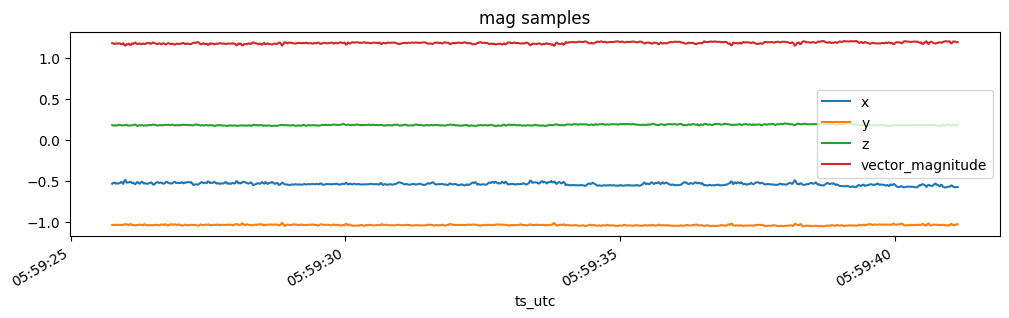


### ppg ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,ambient,channel_samples,ppg0,ppg1,ppg2,raw_sample_timestamp_ns,sample_index
0,2026-05-05 05:59:27.188692480+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.912Z,2026-05-05T05:59:45.042009Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppg-f20f5ed7-55e2-46d1-99b5-123...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,e964d54c-923c-456a-a1c5-8fd52174a302,1,1,high,4340,"[262246, 490877, 471362, 4340]",262246,490877,471362,831275967188692480,0
1,2026-05-05 05:59:27.206874240+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.912Z,2026-05-05T05:59:45.042009Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppg-f20f5ed7-55e2-46d1-99b5-123...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,e964d54c-923c-456a-a1c5-8fd52174a302,1,1,high,4258,"[262319, 491081, 471507, 4258]",262319,491081,471507,831275967206874240,1
2,2026-05-05 05:59:27.225056128+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.912Z,2026-05-05T05:59:45.042009Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppg-f20f5ed7-55e2-46d1-99b5-123...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,e964d54c-923c-456a-a1c5-8fd52174a302,1,1,high,4256,"[262441, 491292, 471707, 4256]",262441,491292,471707,831275967225056128,2
3,2026-05-05 05:59:27.243237888+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.912Z,2026-05-05T05:59:45.042009Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppg-f20f5ed7-55e2-46d1-99b5-123...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,e964d54c-923c-456a-a1c5-8fd52174a302,1,1,high,4287,"[262578, 491549, 472102, 4287]",262578,491549,472102,831275967243237888,3
4,2026-05-05 05:59:27.261419776+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.912Z,2026-05-05T05:59:45.042009Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppg-f20f5ed7-55e2-46d1-99b5-123...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,e964d54c-923c-456a-a1c5-8fd52174a302,1,1,high,4308,"[262595, 491718, 472137, 4308]",262595,491718,472137,831275967261419776,4
5,2026-05-05 05:59:27.279601536+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.912Z,2026-05-05T05:59:45.042009Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppg-f20f5ed7-55e2-46d1-99b5-123...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,e964d54c-923c-456a-a1c5-8fd52174a302,1,1,high,4286,"[262550, 491725, 472010, 4286]",262550,491725,472010,831275967279601536,5
6,2026-05-05 05:59:27.297783424+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.912Z,2026-05-05T05:59:45.042009Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppg-f20f5ed7-55e2-46d1-99b5-123...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,e964d54c-923c-456a-a1c5-8fd52174a302,1,1,high,4336,"[262517, 491590, 471710, 4336]",262517,491590,471710,831275967297783424,6
7,2026-05-05 05:59:27.315965184+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.912Z,2026-05-05T05:59:45.042009Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppg-f20f5ed7-55e2-46d1-99b5-123...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,e964d54c-923c-456a-a1c5-8fd52174a302,1,1,high,4235,"[262324, 491312, 471310, 4235]",262324,491312,471310,831275967315965184,7
8,2026-05-05 05:59:27.334147072+00:00,2026-05-05T05:59:42.957Z,2026-05-05T05:59:44.912Z,2026-05-05T05:59:45.042009Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppg-f20f5ed7-55e2-46d1-99b5-123...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,e964d54c-923c-456a-a1c5-8fd52174a302,1,1,high,4346,"[262098, 490898, 470897, 4346]",262098,490898,470897,831275967334147072,8
9,2026-05-05 05:59:27.352328832+00:00,2026-05-05T05:59:42.957Z,2026

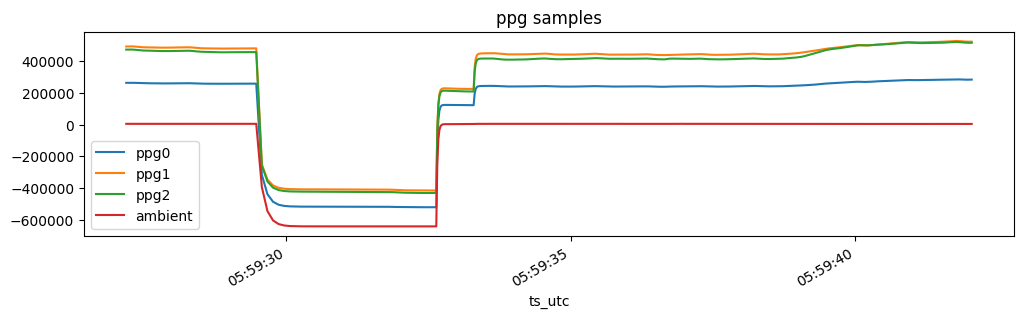


### ppi ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,blocker_bit,hr,pp_error_estimate,pp_in_ms,raw_sample_timestamp_ns,sample_index,skin_contact_status,skin_contact_supported
0,2026-05-05 05:58:05.092000064+00:00,2026-05-05T05:58:24.658Z,2026-05-05T05:58:56.046Z,2026-05-05T05:58:58.424240Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppi-f20f5ed7-55e2-46d1-99b5-123...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,edf453c0-a6d3-47e0-b34a-99cbd184a678,1,1,medium,0,48,16,1033,18014342750481984,22704,1,1
1,2026-05-05 05:58:05.718505682+00:00,2026-05-05T05:58:24.658Z,2026-05-05T05:58:56.046Z,2026-05-05T05:58:58.424240Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppi-f20f5ed7-55e2-46d1-99b5-123...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,edf453c0-a6d3-47e0-b34a-99cbd184a678,1,1,medium,0,41,18,1359,0,22703,1,1
2,2026-05-05 05:58:06.113000064+00:00,2026-05-05T05:58:24.658Z,2026-05-05T05:58:56.046Z,2026-05-05T05:58:58.424240Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppi-f20f5ed7-55e2-46d1-99b5-123...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,edf453c0-a6d3-47e0-b34a-99cbd184a678,1,1,medium,0,48,19,1021,18014343771481984,22705,1,1
3,2026-05-05 05:58:06.345011300+00:00,2026-05-05T05:58:24.658Z,2026-05-05T05:58:56.046Z,2026-05-05T05:58:58.424240Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppi-f20f5ed7-55e2-46d1-99b5-123...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,edf453c0-a6d3-47e0-b34a-99cbd184a678,1,1,medium,0,41,17,1586,0,22702,1,1
4,2026-05-05 05:58:06.971516918+00:00,2026-05-05T05:58:24.658Z,2026-05-05T05:58:56.046Z,2026-05-05T05:58:58.424240Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppi-f20f5ed7-55e2-46d1-99b5-123...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,edf453c0-a6d3-47e0-b34a-99cbd184a678,1,1,medium,0,41,16,1384,0,22701,1,1
5,2026-05-05 05:58:07.175000064+00:00,2026-05-05T05:58:24.658Z,2026-05-05T05:58:56.046Z,2026-05-05T05:58:58.424240Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppi-f20f5ed7-55e2-46d1-99b5-123...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,edf453c0-a6d3-47e0-b34a-99cbd184a678,1,1,medium,0,48,21,1062,18014344833481984,22706,1,1
6,2026-05-05 05:58:07.598022536+00:00,2026-05-05T05:58:24.658Z,2026-05-05T05:58:56.046Z,2026-05-05T05:58:58.424240Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppi-f20f5ed7-55e2-46d1-99b5-123...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,edf453c0-a6d3-47e0-b34a-99cbd184a678,1,1,medium,0,41,357,1120,0,22700,1,1
7,2026-05-05 05:58:07.970000064+00:00,2026-05-05T05:58:24.658Z,2026-05-05T05:58:56.046Z,2026-05-05T05:58:58.424240Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppi-f20f5ed7-55e2-46d1-99b5-123...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,edf453c0-a6d3-47e0-b34a-99cbd184a678,1,1,medium,0,52,14,1106,18014345628481984,25784,1,1
8,2026-05-05 05:58:07.973000064+00:00,2026-05-05T05:58:24.658Z,2026-05-05T05:58:56.046Z,2026-05-05T05:58:58.424240Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppi-f20f5ed7-55e2-46d1-99b5-123...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,edf453c0-a6d3-47e0-b34a-99cbd184a678,1,1,medium,0,51,9,1154,18014345631481984,23100,1,1
9,2026-05-05 05:58:08.224528154+00:00,2026-05-05T05:58:24.658Z,2026-05-05T05:58:56.046Z,2026-05-05T05:58:58.424240Z,f20f5ed7-55e2-46d1-99b5-12368729a254,stream-offline-ppi-f20f5ed7-55e2-46d1-99b5-123...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,edf453c0-a6d3-47e0-b34a-99cbd184a678,1,1,medium,0,45,26,1364,0,22699,1,1


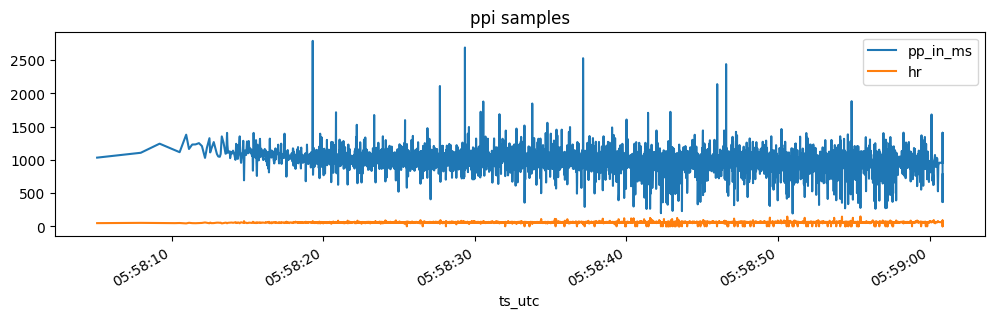

In [10]:
plot_columns = {
    "hr": ["hr", "corrected_hr"],
    "ppi": ["pp_in_ms", "hr"],
    "acc": ["x", "y", "z", "vector_magnitude"],
    "gyro": ["x", "y", "z", "vector_magnitude"],
    "mag": ["x", "y", "z", "vector_magnitude"],
    "ppg": ["ppg0", "ppg1", "ppg2", "ambient"],
}
for stream, df in sorted(clean.items()):
    print(f"\n### {stream} ###")
    if df.empty:
        print("empty")
        continue
    local, ts_col = ensure_datetime(df)
    display(local.head(10))
    if ts_col is None:
        print("no timestamp column")
        continue
    cols = [c for c in plot_columns.get(stream, []) if c in local.columns]
    if not cols:
        print("no plot columns")
        continue
    sampled = local if len(local.index) <= plot_points else local.iloc[::max(1, len(local.index)//plot_points)].copy()
    ax = sampled.plot(x=ts_col, y=cols, figsize=(12, 3), title=f"{stream} samples")
    ax.set_xlabel("ts_utc")
    plt.show()

## I. Session Summary Snapshot

In [11]:
if summary:
    print("status:", summary.get("status"))
    print("streams_present:", summary.get("streams_present"))
    print("streams_missing:", summary.get("streams_missing"))
    display(pd.DataFrame(summary.get("stream_summaries", {})).T[["status","warnings"]])
else:
    print("summary missing")

status: partial
streams_present: ['hr', 'acc', 'ppi', 'gyro', 'mag', 'ppg']
streams_missing: ['ecg', 'battery']


,status,warnings
hr,success,[too few windows]
acc,success,[]
ecg,missing,[empty dataset]
battery,missing,[empty dataset]
ppi,success,[]
gyro,success,[]
mag,success,[]
ppg,success,[]
